7. CpG islands детектор (1 балл)

Цель: реализовать алгоритм поиска CpG островков по критериям Гардинера-Гардена.


Условие: загрузите участок генома человека (например, первые 100 000 нуклеотидов chr1).

Задачи:
1. Реализуйте функцию compute_cpg_ratio(window), которая для окна последовательности вычисля-
ет:
• P (CG) — частоту динуклеотида CG
• P (C) и P (G) — частоты отдельных нуклеотидов
P (CG)
• R(CG) = P (C)×P
(G)
• GC% — процент G и C
2. Просканируйте последовательность скользящим окном размером 200 нуклеотидов.
3. Отметьте участки, где R(CG) > 0.6 и GC% > 50%.
4. Визуализируйте результаты: постройте график, где по оси X — позиция в геноме, по оси Y — значение
R(CG), горизонтальная линия на уровне 0.6.
Ответ: Реализованная функция детектора. Координаты найденных CpG-островков. Построенный график
распределения R(CG) (изображение).

In [7]:
from Bio import SeqIO
import numpy as np
import matplotlib.pyplot as plt

In [8]:
#1
records = SeqIO.parse("chr1.fa", "fasta")
seq = ''.join(str(record.seq).upper() for record in records)
seq = ''.join(base for base in seq if base in "ACGT")
seq = seq[:100000]
alphabet = ['A', 'C', 'G', 'T']
idx = {b: i for i, b in enumerate(alphabet)}

In [9]:
# 2. Функция compute_cpg_ratio(window)
# =========================
def compute_cpg_ratio(window):
    L = len(window)
    if L < 2:
        return {
            "P_CG": 0.0,
            "P_C": 0.0,
            "P_G": 0.0,
            "R_CG": 0.0,
            "GC_percent": 0.0
        }

    count_C = window.count('C')
    count_G = window.count('G')
    count_CG = sum(1 for i in range(L - 1) if window[i:i+2] == 'CG')

    P_C = count_C / L
    P_G = count_G / L
    P_CG = count_CG / (L - 1)

    if P_C == 0 or P_G == 0:
        R_CG = 0.0
    else:
        R_CG = P_CG / (P_C * P_G)

    GC_percent = 100 * (count_C + count_G) / L

    return {
        "P_CG": P_CG,
        "P_C": P_C,
        "P_G": P_G,
        "R_CG": R_CG,
        "GC_percent": GC_percent
    }


In [10]:
# 3. Сканирование окном 200 нуклеотидов

window_size = 200
positions = []
ratios = []
gc_values = []
hits = []

for start in range(0, len(seq) - window_size + 1):
    window = seq[start:start + window_size]
    res = compute_cpg_ratio(window)

    positions.append(start)
    ratios.append(res["R_CG"])
    gc_values.append(res["GC_percent"])

    # Критерии CpG island
    if res["R_CG"] > 0.6 and res["GC_percent"] > 50:
        hits.append((start, start + window_size))


In [11]:
# 4. Объединение перекрывающихся окон в островки
merged_islands = []

for start, end in hits:
    if not merged_islands:
        merged_islands.append([start, end])
    else:
        last_start, last_end = merged_islands[-1]
        if start <= last_end:
            merged_islands[-1][1] = max(last_end, end)
        else:
            merged_islands.append([start, end])


In [12]:
# 5. Вывод координат островков
print("Found CpG islands:")
for i, (start, end) in enumerate(merged_islands, start=1):
    print(f"Island {i}: {start}-{end}, length = {end - start}")

Found CpG islands:
Island 1: 270-1348, length = 1078
Island 2: 6468-6674, length = 206
Island 3: 9246-9472, length = 226
Island 4: 16672-16997, length = 325
Island 5: 18625-19845, length = 1220
Island 6: 26786-27048, length = 262
Island 7: 41433-41990, length = 557
Island 8: 78293-78652, length = 359
Island 9: 93063-93280, length = 217


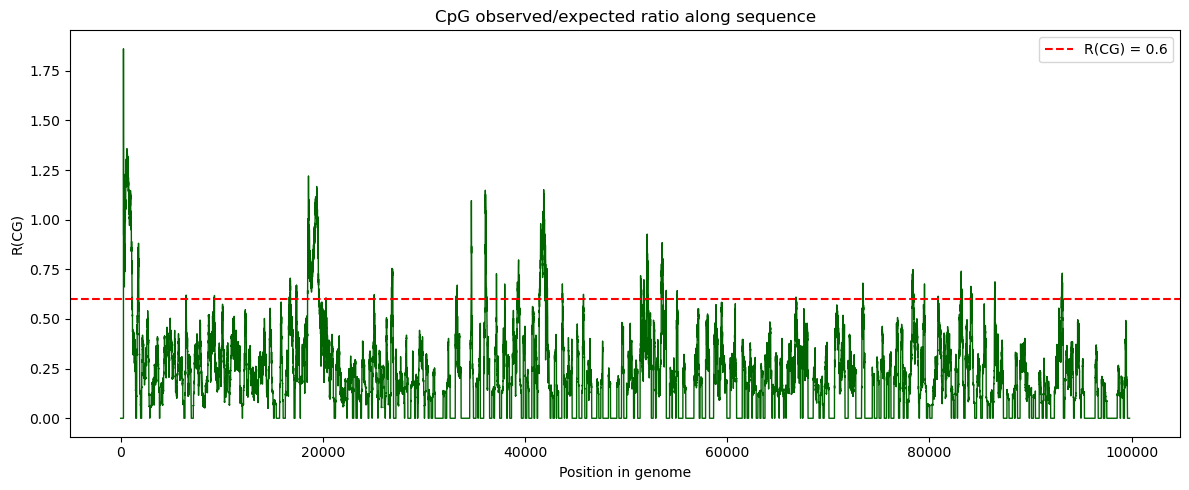

In [13]:
# 6. График распределения R(CG)
# =========================
plt.figure(figsize=(12, 5))
plt.plot(positions, ratios, color='darkgreen', linewidth=1)
plt.axhline(y=0.6, color='red', linestyle='--', label='R(CG) = 0.6')
plt.xlabel('Position in genome')
plt.ylabel('R(CG)')
plt.title('CpG observed/expected ratio along sequence')
plt.legend()
plt.tight_layout()
plt.show()